Total rows: 220
Species x Color found in CSV:
species  color
cat      black     38
         gray      16
dog      brown    142
         white     24

Subgroups to evaluate: ['cat_black', 'cat_gray', 'dog_brown', 'dog_white']

Plot colors assigned:
  cat    / black    → #2b2b2b
  cat    / gray     → #9e9e9e
  dog    / brown    → #8B4513
  dog    / white    → #f0f0f0

── Cat/Black  (38 samples) ──────────────────────────
  Acc : 0.9696
  Dice: 0.9641
  IoU : 0.9308
  Loss: 0.0211

── Cat/Gray  (16 samples) ──────────────────────────
  Acc : 0.9469
  Dice: 0.9385
  IoU : 0.8846
  Loss: 0.0314

── Dog/Brown  (142 samples) ──────────────────────────
  Acc : 0.9631
  Dice: 0.9502
  IoU : 0.9054
  Loss: 0.0272

── Dog/White  (24 samples) ──────────────────────────
  Acc : 0.9666
  Dice: 0.9564
  IoU : 0.9165
  Loss: 0.0240

Subgroup               N   Accuracy     Dice      IoU     Loss
Cat/Black             38     0.9696   0.9641   0.9308   0.0211
Cat/Gray              16     0.9469   0.9385 

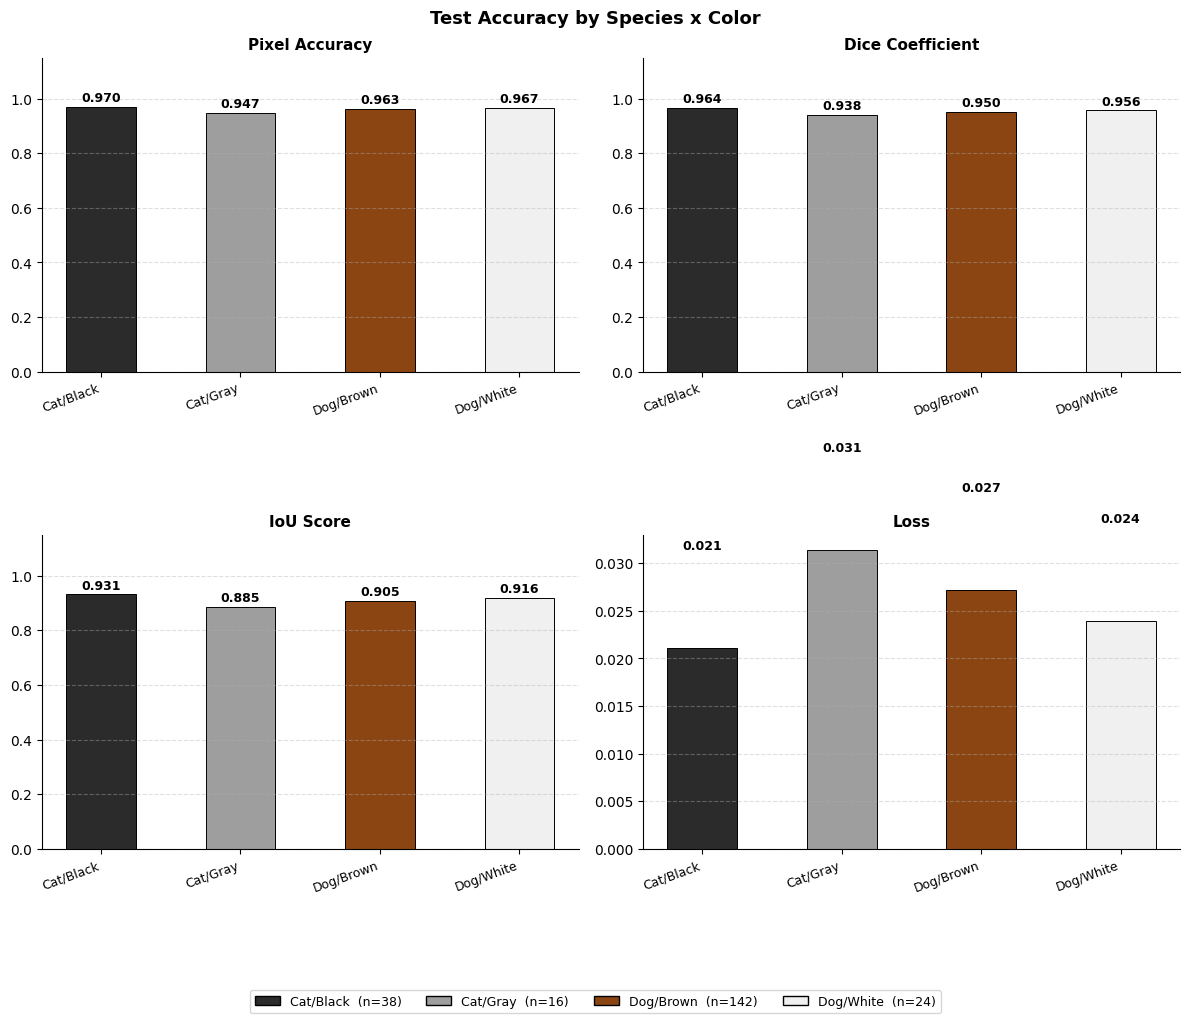

Plot saved → test_subgroup_accuracy.png


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import torch.optim as optim
# ── Config 
ALL_TEST_CSV = "/home/ahsan/test-project/ISIC-2019/Pet_data/pet_fixed_by_label/Metadata/Metadata_final/Cat_black_grey_Dog_brown_white_test_IID.csv"
PET_DATA_ROOT = "/home/ahsan/test-project/ISIC-2019/Pet_data/pet_fixed_by_label"
LR_INITIAL = 1e-4
SPECIES_TO_CLASS = {"background": 0, "cat": 1, "dog": 2}
NUM_CLASSES      = 3
BATCH_SIZE       = 8
DEVICE           = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')

# Exactly the 4 subgroups you want
SUBGROUPS = [
    {"species": "cat", "color": "black"},
    {"species": "cat", "color": "gray"},
    {"species": "dog", "color": "brown"},
    {"species": "dog", "color": "white"},
]

# Bar colors that match the actual animal color
PLOT_COLOR = {
    ("cat", "black") : "#2b2b2b",
    ("cat", "gray")  : "#9e9e9e",
    ("dog", "brown") : "#8B4513",
    ("dog", "white") : "#d3d3d3",
}

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── Load CSV 
df_all = pd.read_csv(ALL_TEST_CSV)
df_all.columns    = df_all.columns.str.strip()
df_all["species"] = df_all["species"].str.lower().str.strip()
df_all["color"]   = df_all["color"].str.lower().str.strip()

print(f"Total rows: {len(df_all)}")
print(f"Species x Color found in CSV:")
print(df_all.groupby(["species", "color"]).size().to_string())

# ── Build SUBGROUPS dynamically from whatever is in the CSV 
SUBGROUPS = [
    {"species": sp, "color": col}
    for (sp, col) in df_all.groupby(["species", "color"]).groups.keys()
]
subgroup_names = [f"{s['species']}_{s['color']}" for s in SUBGROUPS]
print(f"\nSubgroups to evaluate: {subgroup_names}")


# ── COLOR MAPS
COLOR_MAP = {
    "black" : "#2b2b2b",
    "grey"  : "#9e9e9e",
    "gray"  : "#9e9e9e",
    "brown" : "#8B4513",
    "white" : "#f0f0f0",
    "other" : "#5c85d6",  
}

PLOT_COLOR = {
    (sg["species"], sg["color"]): COLOR_MAP.get(sg["color"], "#5c85d6")
    for sg in SUBGROUPS
}

print(f"\nPlot colors assigned:")
for k, v in PLOT_COLOR.items():
    print(f"  {k[0]:6s} / {k[1]:8s} → {v}")

# ── Dataset 
class PetSubgroupDataset(Dataset):
    def __init__(self, sub_df, data_root, transform=None):
        self.df        = sub_df.reset_index(drop=True)
        self.data_root = data_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        img_path  = os.path.join(self.data_root, row["image"])
        mask_path = os.path.join(self.data_root, row["mask"])
        species   = str(row["species"]).lower().strip()

        image       = np.array(Image.open(img_path).convert("RGB"))
        binary_mask = np.array(Image.open(mask_path).convert("L")) > 127
        species_cls = SPECIES_TO_CLASS[species]
        mask        = np.zeros(binary_mask.shape, dtype=np.int64)
        mask[binary_mask] = species_cls

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"]

        if not isinstance(mask, torch.Tensor):
            mask = torch.as_tensor(mask)
        if mask.ndim == 3:
            mask = mask.squeeze(0)
        if mask.is_floating_point():
            mask = mask.round()

        return image, mask.long()

# ── Metrics 
def compute_metrics(outputs, masks, num_classes, smooth=1e-6):
    """
    outputs : [B, C, H, W] raw logits
    masks   : [B, H, W]    long ground truth
    """
    preds = outputs.argmax(dim=1) # [B, H, W]

    acc = (preds == masks).float().mean().item()

    preds_flat = preds.view(-1)   # [B * H * W]
    masks_flat = masks.view(-1)   # [B * H * W]

    preds_one_hot = F.one_hot(preds_flat, num_classes=num_classes).float()
    masks_one_hot = F.one_hot(masks_flat, num_classes=num_classes).float()

    inter = (preds_one_hot * masks_one_hot).sum(dim=0)
    total_preds = preds_one_hot.sum(dim=0)
    total_masks = masks_one_hot.sum(dim=0)
    union = total_preds + total_masks - inter

    inter = inter[1:]
    union = union[1:]
    total_preds = total_preds[1:]
    total_masks = total_masks[1:]

    class_present = (total_masks > 0)

    if class_present.sum() == 0:
        # Avoid division by zero if no foreground classes exist in the batch
        return {"acc": acc, "dice": 0.0, "iou": 0.0}

    dice_per_class = (2 * inter + smooth) / (total_preds + total_masks + smooth)
    iou_per_class = (inter + smooth) / (union + smooth)

    mean_dice = dice_per_class[class_present].mean().item()
    mean_iou = iou_per_class[class_present].mean().item()

    return {
        "acc"  : acc,
        "dice" : mean_dice,
        "iou"  : mean_iou,
    }

# Model: U-Net with ResNet34 backbone (in_channels must match RGB input from the dataset)
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
).to(DEVICE)

# Loss Function: Dice Loss for multi-class segmentation (cat vs dog + background)
criterion = smp.losses.DiceLoss(mode="multiclass", from_logits=True)

DEVICE = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
""" Load Already fine-tuned model """
checkpoint_path = '/home/ahsan/test-project/ISIC-2019/Pet_data/checkpoints/multiseed/UNet_multiclass_seed42_epoch100.pth'
#checkpoint_path = '/home/ahsan/test-project/ISIC-2019/Pet_data/UNet_Pet_Seg_multiclass_All_epoch100_2.pth'
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()
# ── Build subgroup loaders & evaluate 
results = {}   
for sg in SUBGROUPS:
    species = sg["species"]
    color   = sg["color"]
    key     = f"{species}_{color}"
    label   = f"{species.capitalize()}/{color.capitalize()}"

    sub_df = df_all[
        (df_all["species"] == species) &
        (df_all["color"]   == color)
    ]

    print(f"\n── {label}  ({len(sub_df)} samples) ")

    dataset = PetSubgroupDataset(sub_df, PET_DATA_ROOT, transform=val_transform)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)

    tot_acc = tot_dice = tot_iou = tot_loss = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)

            tot_loss += criterion(outputs, masks).item()
            m         = compute_metrics(outputs, masks, NUM_CLASSES)
            tot_acc  += m["acc"]
            tot_dice += m["dice"]
            tot_iou  += m["iou"]

    n = len(loader)
    results[key] = {
        "label"   : label,
        "species" : species,
        "color"   : color,
        "n"       : len(sub_df),
        "loss"    : tot_loss / n,
        "acc"     : tot_acc  / n,
        "dice"    : tot_dice / n,
        "iou"     : tot_iou  / n,
    }

    print(f"  Acc : {results[key]['acc']:.4f}")
    print(f"  Dice: {results[key]['dice']:.4f}")
    print(f"  IoU : {results[key]['iou']:.4f}")
    print(f"  Loss: {results[key]['loss']:.4f}")

# ── Console table 
print("\n" + "="*65)
print(f"{'Subgroup':<18} {'N':>5} {'Accuracy':>10} {'Dice':>8} {'IoU':>8} {'Loss':>8}")
print("="*65)
for key, m in results.items():
    print(f"{m['label']:<18} {m['n']:>5} {m['acc']:>10.4f} "
          f"{m['dice']:>8.4f} {m['iou']:>8.4f} {m['loss']:>8.4f}")
print("="*65)

# ── Plot 
keys       = list(results.keys())
labels     = [results[k]["label"] for k in keys]
bar_colors = [PLOT_COLOR[(results[k]["species"], results[k]["color"])] for k in keys]
x          = np.arange(len(keys))

metrics_cfg = [
    ("acc",  "Pixel Accuracy"),
    ("dice", "Dice Coefficient"),
    ("iou",  "IoU Score"),
    ("loss", "Loss"),
]

fig, axes = plt.subplots(2, 2, figsize=(max(12, len(keys) * 2), 10))
fig.suptitle("Test Accuracy by Species x Color", fontsize=13, fontweight='bold')

for ax, (metric, title) in zip(axes.flat, metrics_cfg):
    values = [results[k][metric] for k in keys]
    bars   = ax.bar(x, values, color=bar_colors,
                    edgecolor='black', linewidth=0.7, width=0.5)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.15 if metric != "loss" else None)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend with sample counts
legend_handles = [
    mpatches.Patch(
        facecolor=PLOT_COLOR[(results[k]["species"], results[k]["color"])],
        edgecolor='black',
        label=f"{results[k]['label']}  (n={results[k]['n']})"
    )
    for k in keys
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=min(len(keys), 5),          # max 5 per row
    bbox_to_anchor=(0.5, -0.03),
    fontsize=9, frameon=True
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("test_subgroup_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → test_subgroup_accuracy.png")